# BrushCue Example: Watercolor Effect

<a href="https://colab.research.google.com/github/ditotechnologies/brushcue/blob/main/examples/watercolor_effect.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

You can use this tool online at https://www.brushcue.com/tools/watercolor-effect

In [ ]:
!pip install brushcue

[wgpu] using backend Metal — adapter 'Apple M5' (IntegratedGpu), driver ''


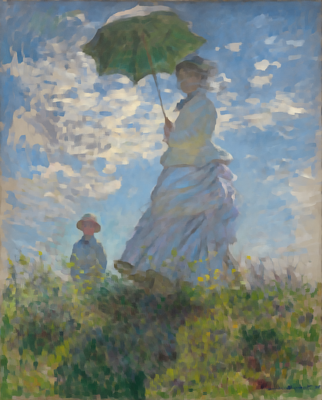

In [1]:
import io
from PIL import Image
import brushcue as bc

wash_size = 6.0
pigment_strength = 1.0
edge_pooling = 0.35
paper_texture = 0.35
# Replace this with bc.Composition.from_path("your-photo.jpg") for your own image.
input_image = bc.Composition.monet_women_with_parasol()
bounds = input_image.bounds()
reference_scale = (
    bc.Float.max(1.0, bc.Float.min(bounds.width(), bounds.height())) / 1000.0
)
radius = bc.Float.max(0.5, wash_size * reference_scale)
washed = input_image.spacial_effect_shader(
    "let lo = image_bounds.xy + vec2f(0.5);\nlet hi = image_bounds.zw - vec2f(0.5);\nlet p = clamp(position, lo, hi);\nlet center = sample(p);\nlet uv = (p - image_bounds.xy) / reference_scale;\nlet jitter = vec2f(noise(uv / 19.0), noise(uv / 19.0 + vec2f(37.0, 13.0))) - vec2f(0.5);\nlet origin = p + jitter * radius * 0.3;\nvar sums: array<vec3f, 4>;\nvar squares: array<vec3f, 4>;\nvar counts: array<f32, 4>;\nfor (var y = -3; y <= 3; y = y + 1) {\n    for (var x = -3; x <= 3; x = x + 1) {\n        let q = clamp(origin + vec2f(f32(x), f32(y)) * radius / 3.0, lo, hi);\n        let c = sample(q);\n        for (var k = 0; k < 4; k = k + 1) {\n            let in_x = select(x >= 0, x <= 0, (k % 2) == 0);\n            let in_y = select(y >= 0, y <= 0, k < 2);\n            if (in_x && in_y) {\n                sums[k] += c.rgb * c.a;\n                squares[k] += c.rgb * c.rgb * c.a;\n                counts[k] += c.a;\n            }\n        }\n    }\n}\nvar means: array<vec3f, 4>;\nvar variances: array<f32, 4>;\nvar min_variance = 1e6;\nfor (var k = 0; k < 4; k = k + 1) {\n    means[k] = sums[k] / max(counts[k], 0.0001);\n    let variance = max(squares[k] / max(counts[k], 0.0001) - means[k] * means[k], vec3f(0.0));\n    variances[k] = dot(variance, vec3f(1.0, 0.25, 0.25));\n    if (counts[k] > 0.0001) { min_variance = min(min_variance, variances[k]); }\n}\nvar color = vec3f(0.0);\nvar total_weight = 0.0;\nfor (var k = 0; k < 4; k = k + 1) {\n    let ratio = (min_variance + 0.0001) / (variances[k] + 0.0001);\n    let weight = select(0.0, pow(clamp(ratio, 0.0, 1.0), 4.0), counts[k] > 0.0001);\n    color += means[k] * weight;\n    total_weight += weight;\n}\nlet wash = select(center.rgb, color / max(total_weight, 0.0001), total_weight > 0.0001);\nreturn vec4f(mix(center.rgb, wash, 0.9), center.a);",
    "fn hash(p: vec2f) -> f32 {\n    let q = fract(p * vec2f(0.1031, 0.11369));\n    let n = dot(q, q.yx + vec2f(19.19));\n    return fract((q.x + q.y + n) * (q.x + n));\n}\nfn noise(p: vec2f) -> f32 {\n    let i = floor(p);\n    let f = fract(p);\n    let u = f * f * (vec2f(3.0) - 2.0 * f);\n    return mix(mix(hash(i), hash(i + vec2f(1.0, 0.0)), u.x),\n        mix(hash(i + vec2f(0.0, 1.0)), hash(i + vec2f(1.0)), u.x), u.y);\n}",
    0.0,
    bc.Dictionary.create()
    .add("image_bounds", bounds)
    .add("reference_scale", reference_scale)
    .add("radius", radius),
    bc.ColorRepresentation.oklab_a(),
).crop(bounds)
graph = washed.spacial_effect_shader(
    "let lo = image_bounds.xy + vec2f(0.5);\nlet hi = image_bounds.zw - vec2f(0.5);\nlet p = clamp(position, lo, hi);\nlet center = sample(p);\nlet rgb = clamp(center.rgb, vec3f(0.0), vec3f(1.0));\nlet l = dot(rgb, vec3f(0.299, 0.587, 0.114));\nvar local_l = 0.0;\nvar alpha = 0.0;\nfor (var y = -1; y <= 1; y = y + 1) {\n    for (var x = -1; x <= 1; x = x + 1) {\n        let c = sample(clamp(p + vec2f(f32(x), f32(y)) * max(0.5, radius * 0.5), lo, hi));\n        local_l += dot(clamp(c.rgb, vec3f(0.0), vec3f(1.0)), vec3f(0.299, 0.587, 0.114)) * c.a;\n        alpha += c.a;\n    }\n}\nlet darker_side = max(local_l / max(alpha, 0.0001) - l, 0.0);\nlet pool = edge_pooling * 0.10 * smoothstep(0.015, 0.12, darker_side);\nlet uv = (p - image_bounds.xy) / reference_scale;\nlet fine = noise(uv * 0.75);\nlet coarse = noise(uv / 35.0 + vec2f(17.0, 53.0));\nlet pigment = 1.0 - l;\nlet variation = paper_texture * pigment * ((fine - 0.5) * 0.30 + (coarse - 0.5) * 0.18);\nlet density = clamp(pigment_strength * (1.0 + variation), 0.35, 2.5);\nlet paint = pow(max(rgb, vec3f(0.0001)), vec3f(density));\nlet pooled = paint * (1.0 - pool);\nlet paper = vec3f(1.0 - paper_texture * 0.025 * fine);\nlet result = mix(paper, pooled * paper, 0.95);\nreturn vec4f(clamp(result, vec3f(0.0), vec3f(1.0)), center.a);",
    "fn hash(p: vec2f) -> f32 {\n    let q = fract(p * vec2f(0.1031, 0.11369));\n    let n = dot(q, q.yx + vec2f(19.19));\n    return fract((q.x + q.y + n) * (q.x + n));\n}\nfn noise(p: vec2f) -> f32 {\n    let i = floor(p);\n    let f = fract(p);\n    let u = f * f * (vec2f(3.0) - 2.0 * f);\n    return mix(mix(hash(i), hash(i + vec2f(1.0, 0.0)), u.x),\n        mix(hash(i + vec2f(0.0, 1.0)), hash(i + vec2f(1.0)), u.x), u.y);\n}",
    0.0,
    bc.Dictionary.create()
    .add("image_bounds", bounds)
    .add("reference_scale", reference_scale)
    .add("radius", radius)
    .add("pigment_strength", pigment_strength)
    .add("edge_pooling", edge_pooling)
    .add("paper_texture", paper_texture),
    bc.ColorRepresentation.srgb(),
).crop(bounds)

ctx = bc.Context()
composition = graph.execute(ctx)
img = Image.open(io.BytesIO(composition.to_image_bytes(ctx)))
img.thumbnail((400, 400))
img
